In [26]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv('stock_data.csv')

In [28]:
df.head()

,Open,Close,High,Low,Volume,RSI,MACD,Bollinger_Upper,Bollinger_Lower,Sentiment_Score,GDP_Growth,Inflation_Rate,Target
0,0.374639,0.374780,0.373510,0.378390,0.298909,0.847286,0.741715,0.367146,0.366420,0.877177,0.580868,0.038604,0
1,0.950982,0.937746,0.938422,0.946158,0.094805,0.494543,0.881343,0.938396,0.935640,0.907192,0.527044,0.108908,0
2,0.732198,0.719825,0.723644,0.723158,0.126348,0.195471,0.463179,0.710666,0.702300,0.378363,0.351052,0.432540,0
3,0.598823,0.599865,0.596973,0.605322,0.180662,0.736684,0.289076,0.593793,0.586936,0.231614,0.493274,0.946349,0
4,0.156053,0.163410,0.155891,0.166084,0.203646,0.418698,0.318761,0.164158,0.156355,0.191642,0.365116,0.074867,0


In [29]:
df.shape

(10000, 13)

In [30]:
x = df.iloc[:,0:13]
y = df.iloc[:,-1]

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.8,random_state=42)

In [32]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

1.0

In [47]:
from sklearn.preprocessing import StandardScaler
si = StandardScaler()
x_train = si.fit_transform(x_train)
x_test = si.transform(x_test)

In [48]:
from sklearn.decomposition import PCA
pca = PCA(n_components=6)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [49]:
pca.explained_variance_ratio_

array([0.47089974, 0.08160199, 0.07992442, 0.07854042, 0.07663266,
       0.07496596])

In [50]:
np.cumsum(pca.explained_variance_ratio_)

array([0.47089974, 0.55250172, 0.63242614, 0.71096655, 0.78759922,
       0.86256518])

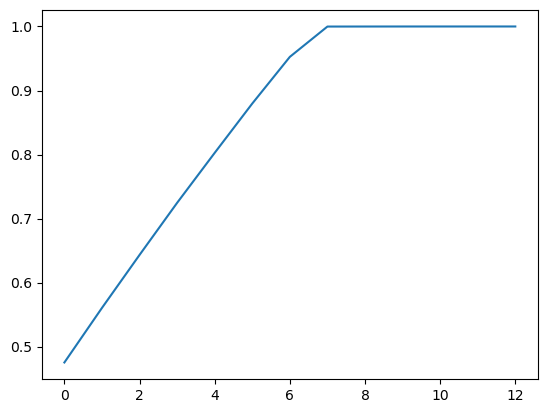

In [41]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [51]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

lr.fit(x_train_trf, y_train)

y_pred = lr.predict(x_test_trf)

from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.95825